Read the data

In [ ]:
# output : csv data
import os
import pandas as pd

for file in os.listdir("../data"):
    df = pd.read_parquet(f"../data/{file}")
    csv_file_name = file.replace(".parquet", ".csv")
    df.to_csv(f"csv_data/{csv_file_name}", index=False)

In [200]:
# details of the data
lidar_data_df = pd.read_parquet("../data/lidar_cable_points_easy.parquet")
print(lidar_data_df.head())
print(lidar_data_df.columns)
print(lidar_data_df.shape)

              x          y          z
2211   6.196634 -13.157755  10.582272
2905 -10.440643  17.264460  10.926065
1411   2.977432  -3.552676  10.072814
251    5.924494 -10.974960  10.342501
794   -7.062873  12.850664  10.557997
Index(['x', 'y', 'z'], dtype='object')
(1502, 3)


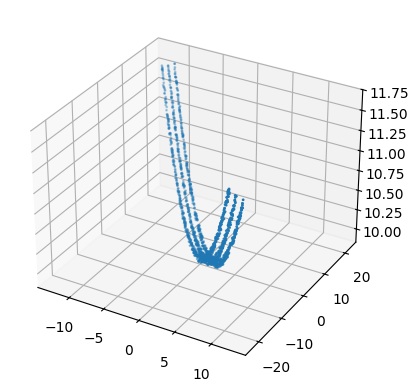

In [201]:
# looks like x, y, z are the column coordinates, check in graphical form
import matplotlib.pyplot as plt
blank_canvas = plt.figure().add_subplot(111, projection="3d")
blank_canvas.scatter(lidar_data_df["x"], lidar_data_df["y"], lidar_data_df["z"], s=1)
plt.savefig("images/lidar_data_visualization.png")

Clustering

In [202]:
# numpy array
coordinates = lidar_data_df[["x", "y", "z"]].values
print(coordinates)

[[  6.19663435 -13.15775512  10.58227233]
 [-10.44064287  17.26446014  10.92606471]
 [  2.97743169  -3.55267568  10.0728142 ]
 ...
 [ -9.74456296  19.54896042  11.2729797 ]
 [ -2.06073546   5.73005863  10.09060331]
 [ 11.12628854 -18.49790267  11.07095826]]


In [204]:
# clustering and no. of clusters
from sklearn.cluster import DBSCAN
db_scan = DBSCAN(eps=0.76, min_samples=5)
labels = db_scan.fit_predict(coordinates)
print(f"Unique clusters: {set(labels)}")

Unique clusters: {0, 1, 2}


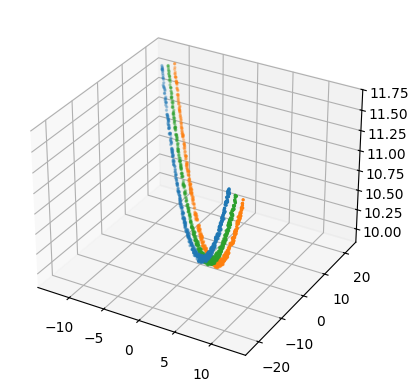

In [205]:
# cluster list visualization
blank_canvas = plt.figure().add_subplot(111, projection="3d")
for cluster_id in set(labels):
    if cluster_id == -1:
        continue
    cluster_points = coordinates[labels == cluster_id]
    blank_canvas.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], s=2)
plt.savefig("images/cluster_list_visualization.png")

Converting 3D->2D

In [211]:
# first cluster details
cluster_0 = coordinates[labels == 0]
print(cluster_0.shape)
print(cluster_0[:5])

(492, 3)
[[  6.19663435 -13.15775512  10.58227233]
 [-10.44064287  17.26446014  10.92606471]
 [ -2.50918664   2.69306205   9.98014699]
 [  0.74506388  -3.17270396  10.06012948]
 [  2.18217254  -5.84324253  10.08796267]]


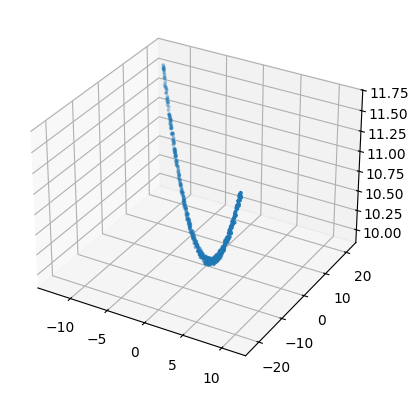

In [212]:
# cluster visualization
blank_canvas = plt.figure().add_subplot(111, projection="3d")
blank_canvas.scatter(cluster_0[:, 0], cluster_0[:, 1], cluster_0[:, 2], s=3)
plt.show()

In [213]:
# 3D to 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
transformed_coordinates = pca.fit_transform(cluster_0)
flatten_2d_points = transformed_coordinates[:, :2]
print(flatten_2d_points[:5])
print("PCA components = ")
print(pca.components_)

[[-1.41528528e+01  5.60401194e-03]
 [ 2.05199690e+01  4.78325091e-01]
 [ 3.93345153e+00 -5.29284572e-01]
 [-2.77466075e+00 -4.74231519e-01]
 [-5.80734949e+00 -4.57681461e-01]]
PCA components = 
[[-4.79351920e-01  8.77614898e-01 -3.71851376e-03]
 [-1.49677790e-03  3.41950040e-03  9.99993033e-01]
 [ 8.77621499e-01  4.79354147e-01 -3.25549503e-04]]


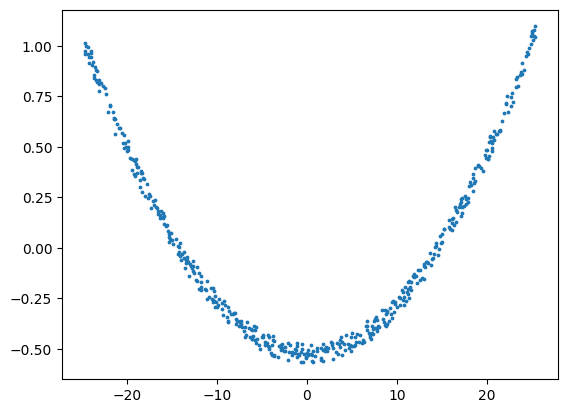

In [214]:
#first cluster visualization - transformed to 2D
blank_canvas = plt.figure().add_subplot(111)
blank_canvas.scatter(flatten_2d_points[:, 0], flatten_2d_points[:, 1], s=3)
plt.show()

Curve best fit for the first cluster

In [215]:
# Catanary curve equation
import numpy as np
def curve_equation(x, x0, y0, c):
    return y0 + c * (np.cosh((x - x0) / c) - 1)


In [216]:
from scipy.optimize import curve_fit
x_data = flatten_2d_points[:, 0]
y_data= flatten_2d_points[:, 1]
initial_assumption_values = [np.mean(x_data), np.min(y_data), 100]
params, covariance = curve_fit(curve_equation, x_data, y_data, p0 = initial_assumption_values)
x0, y0, c = params
print("x0 = ", float(x0))
print("y0 = ", float(y0))
print("c = ", float(c))

x0 =  -6.35444723037488e-16
y0 =  -0.5203781066915865
c =  199.76360264082862


/var/folders/r1/0zy0ybkd79n2tbxg428ygnmc0000gn/T/ipykernel_35994/4090854707.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(curve_equation, x_data, y_data, p0 = initial_assumption_values)
